# 1. Импорт библиотек


In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 2. Загрузка и первый взгляд на данные

In [52]:
df = pd.read_csv('advertising.csv')
display(df.head())
print(df.info())
print(df.describe())

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


# 3. Подготовка данных

In [53]:
features = ['TV', 'Radio', 'Newspaper']
X = df[features]
y = df['Sales']

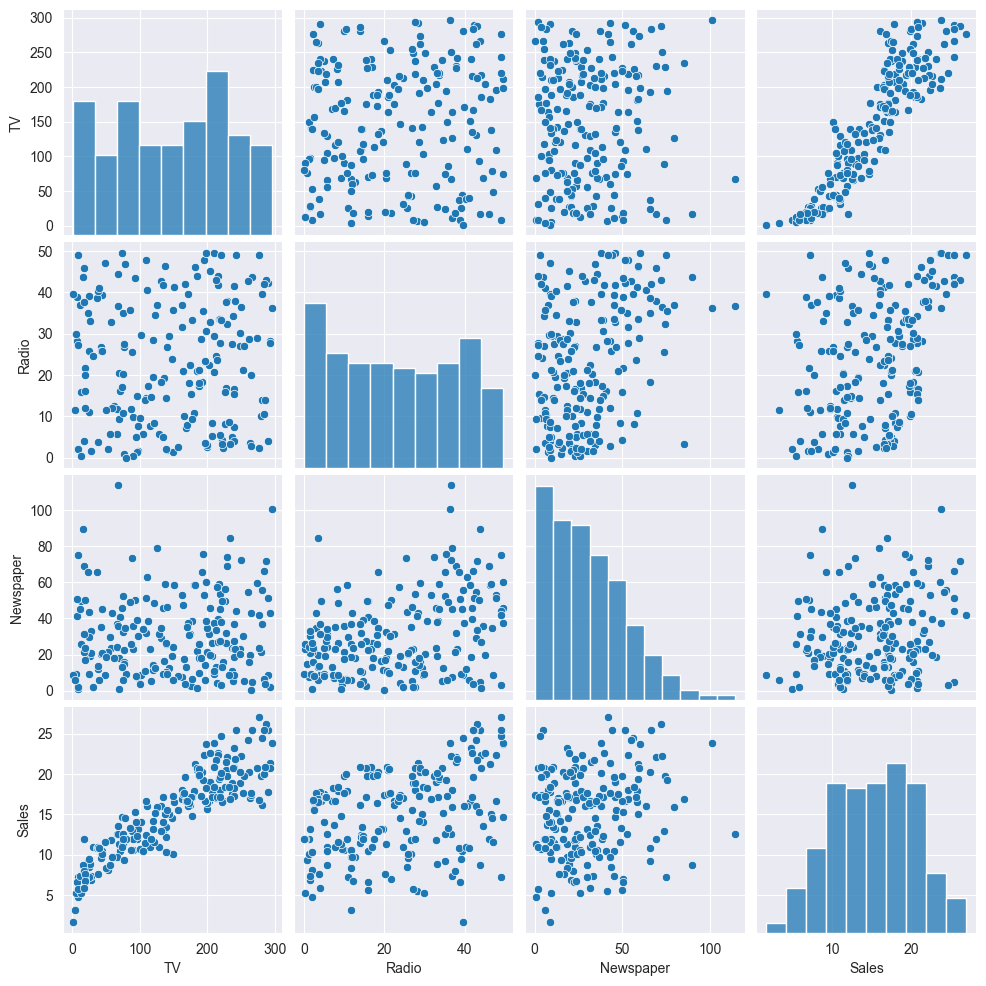

In [54]:
g=sns.pairplot(df[['TV', 'Radio', 'Newspaper', 'Sales']],)

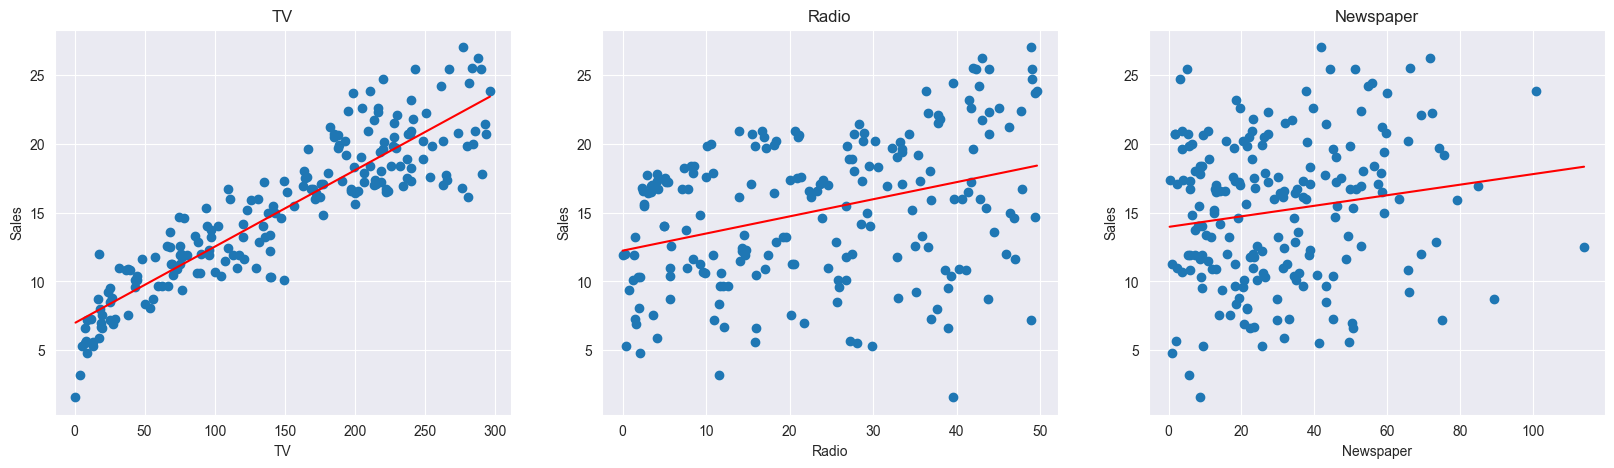

In [55]:
plt.figure(figsize=(20,5))
for i, col in enumerate(features):
    plt.subplot(1,3,i+1)
    x=df[col]
    y=df.Sales
    plt.plot(x,y,'o')
    plt.plot(np.unique(x), np.poly1d(np.polyfit(x,y,1))(np.unique(x)),color='r')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Sales')

# 4. Разделение на обучающую и тестовую выборки

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

# 5. Стандартизация признаков

In [57]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Обучение простой модели регрессии

In [58]:
regr = SGDRegressor(random_state=42)
regr.fit(X_train_scaled, y_train)
y_pred = regr.predict(X_test_scaled)
y_pred

array([10.66733565,  8.64919614,  9.58439492, 25.05763805, 14.74946916,
        8.37193244, 10.79009071, 18.34471736, 10.03468511, 17.85839944,
       23.59031057, 10.69878069, 13.33690575, 17.06959414, 11.75747366,
       13.28054722, 21.09029435,  9.06932887, 14.27583982, 18.84693946,
       25.10310092, 12.38650313, 16.62884871, 13.85510437,  7.78399427,
       15.10339156, 14.67757804, 20.69526768, 16.96341018,  8.97333552,
       12.75257652, 21.00270947, 21.36826002, 21.89294658,  7.27170952,
        7.04306885,  9.30584232, 15.74237545, 13.35438246,  7.28407654,
       11.12538179,  9.03424446, 15.57972376, 18.18972597, 19.01755403,
       13.43738349,  5.30363749, 10.71003014, 15.75955912, 10.989939  ,
       12.21267096, 20.80492591, 20.71692495, 16.95164983,  9.94834356,
        9.42038121, 23.64518876, 15.99797706, 18.07873746,  8.27607623,
       19.33898412, 15.62950611, 17.04696147, 15.24246343, 18.3570046 ,
       20.24477579])

# 7. Оценка качества модели

In [59]:
mae = metrics.mean_absolute_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)
print(f'MAE: {mae:.3f}  R^2: {r2:.3f}')

MAE: 1.348  R^2: 0.867


# 8. Визуализация — сравнение предсказаний и настоящих значений

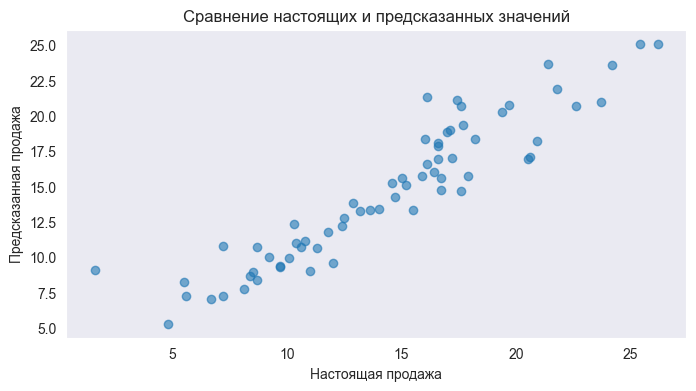

In [60]:
plt.figure(figsize=(8, 4))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel('Настоящая продажа')
plt.ylabel('Предсказанная продажа')
plt.title('Сравнение настоящих и предсказанных значений')
plt.grid()
plt.show()

### Собираем пайплайн

In [61]:
from sklearn.pipeline import Pipeline

pipe=Pipeline(steps=[('scaling',scaler),('regression',regr)])
pipe.fit(X_train,y_train)
print(round(metrics.mean_absolute_error(y_test,pipe.predict(X_test)),3))

1.348


In [62]:
pipe.get_params().keys()

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'scaling', 'regression', 'scaling__copy', 'scaling__with_mean', 'scaling__with_std', 'regression__alpha', 'regression__average', 'regression__early_stopping', 'regression__epsilon', 'regression__eta0', 'regression__fit_intercept', 'regression__l1_ratio', 'regression__learning_rate', 'regression__loss', 'regression__max_iter', 'regression__n_iter_no_change', 'regression__penalty', 'regression__power_t', 'regression__random_state', 'regression__shuffle', 'regression__tol', 'regression__validation_fraction', 'regression__verbose', 'regression__warm_start'])

In [63]:
from sklearn.model_selection import GridSearchCV



parameters_grid={
    'regression__loss':['huber','squared_loss',],
    'regression__n_iter_no_change':[ 5,10,20],
    'regression__penalty':['l1','l2','none'],
    'regression__alpha':[0.0001,0.001,0.1],
}
grid_cv=GridSearchCV(pipe,parameters_grid,scoring='neg_mean_absolute_error',cv=4)

grid_cv.fit(X_train, y_train)

C:\Users\MaxxPC\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
144 fits failed out of a total of 216.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
36 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\MaxxPC\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\MaxxPC\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\MaxxPC\AppData\Local\Programs\Python\Python39\lib\site-packa

GridSearchCV(cv=4,
             estimator=Pipeline(steps=[('scaling', StandardScaler()),
                                       ('regression',
                                        SGDRegressor(random_state=42))]),
             param_grid={'regression__alpha': [0.0001, 0.001, 0.1],
                         'regression__loss': ['huber', 'squared_loss'],
                         'regression__n_iter_no_change': [5, 10, 20],
                         'regression__penalty': ['l1', 'l2', 'none']},
             scoring='neg_mean_absolute_error')

In [64]:
print(round(-1*grid_cv.best_score_, 3))
print(grid_cv.best_params_)

13.937
{'regression__alpha': 0.0001, 'regression__loss': 'huber', 'regression__n_iter_no_change': 20, 'regression__penalty': 'l2'}


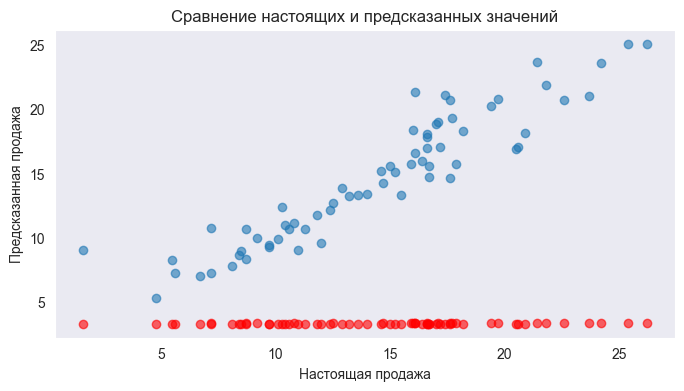

In [65]:
plt.figure(figsize=(8, 4))
plt.scatter(y_test, pipe.predict(X_test), alpha=0.6)
plt.scatter(y_test,grid_cv.best_estimator_.predict(X_test),color="r",alpha=0.6)
plt.xlabel('Настоящая продажа')
plt.ylabel('Предсказанная продажа')
plt.title('Сравнение настоящих и предсказанных значений')
plt.grid()
plt.show()

# 10. Корреляция признаков и продажи

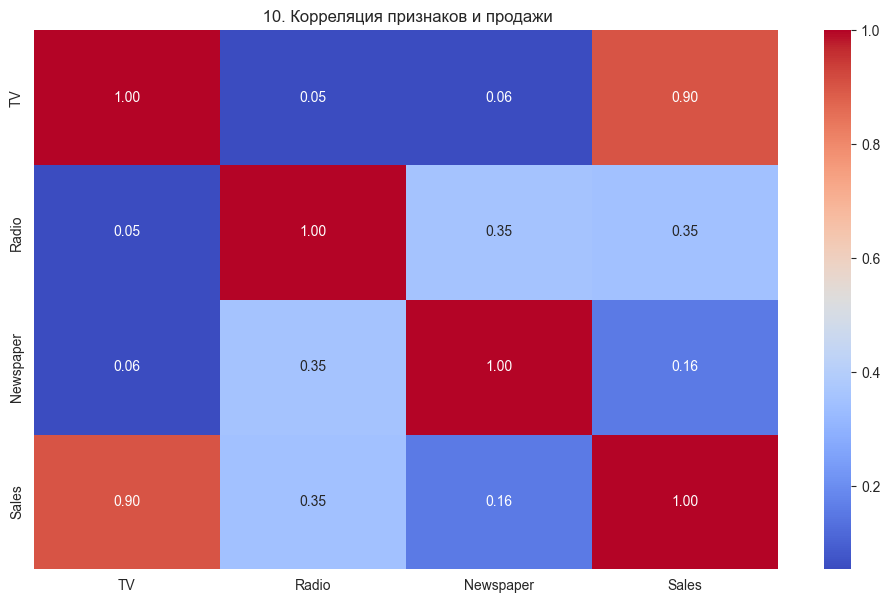

In [66]:
corr = df[features+['Sales']].corr()
plt.figure(figsize=(12,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title(' 10. Корреляция признаков и продажи')
plt.show()

## Случайный лес

1.099


C:\Users\MaxxPC\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
144 fits failed out of a total of 216.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
36 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\MaxxPC\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\MaxxPC\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\MaxxPC\AppData\Local\Programs\Python\Python39\lib\site-packa

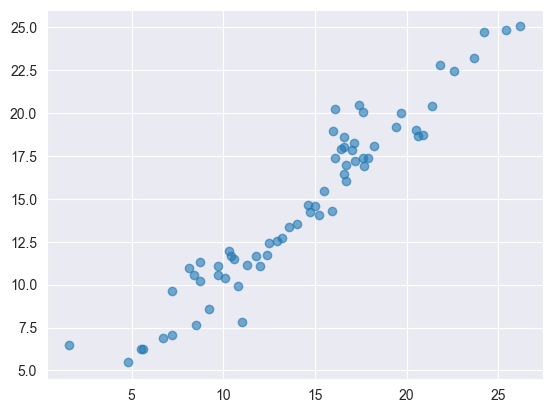

In [67]:
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(random_state=42)
rfr.fit(X_train, y_train)
rf_predict = rfr.predict(X_test)
print(round(metrics.mean_absolute_error(y_test, rf_predict),3))

grid_cv = GridSearchCV(pipe, parameters_grid, scoring='neg_mean_absolute_error', cv=4)
grid_cv.fit(X_train, y_train)
plt.scatter(y_test, rf_predict,alpha=0.6)